# Diabetic Retinopathy Stage Detection with Transfer Learning
**Module:** Computer Vision (BSc (Hons) Computer Science, BSCCOMP24.2P)

This notebook classifies retinal fundus photographs from the APTOS 2019 Kaggle dataset into the five diabetic retinopathy (DR) stages. It also derives two clinically used binary decisions: **any DR vs. no DR** and **referable DR (stage ≥ 2)**.




## 0. Environment setup

Confirm that a GPU is attached. Training the network on a CPU alone would take many hours.

In [1]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-c8f83338-11d2-c49a-9e11-4833f34f9cc8)
GPU 1: Tesla T4 (UUID: GPU-697f3291-d9c5-aaa9-7a40-5914a2e2b7f7)


Install the one extra library used later: `gradio` for the interactive prototype in Section 12. All other libraries are already in the Kaggle image.

In [2]:
!pip install -q gradio

Import every library used in the notebook and fix all random seeds (Python, NumPy, TensorFlow) so the split, augmentation and weight initialisation are reproducible.

`TF_CPP_MIN_LOG_LEVEL` is set **before** TensorFlow is imported, which hides TensorFlow's informational GPU log lines.

In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # hide TensorFlow info/warning logs

import gc, glob, json, random, time, warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from joblib import Parallel, delayed

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             cohen_kappa_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             precision_recall_fscore_support)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print('TensorFlow:', tf.__version__, '| Keras:', keras.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0 | Keras: 3.13.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


All tunable settings in one place. Changing a value here changes it for the whole notebook, which keeps experiments controlled and reproducible.

The two `RUN_*` flags switch the extra experiments on or off. Set them to `False` to save about 10 minutes if you are short on GPU time.

In [4]:
CONFIG = {
    'IMG_SIZE': 224,              # EfficientNetB0 native input size
    'BATCH_SIZE': 32,
    'PREPROCESS_MODE': 'clahe_edge',   # 'clahe_edge' (main), 'ben_graham' (alternative) or 'raw'
    'MIN_CLASS_RATIO': 0.5,       # every class oversampled to at least 50% of the majority class
    'LABEL_SMOOTHING': 0.05,

    # Extra experiments
    'RUN_BACKBONE_COMPARISON': True,
    'COMPARE_EPOCHS': 5,
    'RUN_HPARAM_SEARCH': True,
    'SEARCH_EPOCHS': 4,

    # Final training (defaults; replaced by the search results when the search runs)
    'BACKBONE': 'EfficientNetB0',
    'HEAD_LR': 1e-3,
    'DENSE_UNITS': 256,
    'DROPOUT': 0.3,
    'PHASE1_EPOCHS': 8,
    'PHASE2_EPOCHS': 25,
    'FINETUNE_LR': 5e-5,
    'FINETUNE_FRACTION': 1.0,     # fraction of backbone layers unfrozen in phase 2 (BatchNorm stays frozen)
}

OUT_DIR = '/kaggle/working'
FIG_DIR = f'{OUT_DIR}/figures'
CACHE_DIR = '/tmp/dr_cache'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

IMG_SIZE = CONFIG['IMG_SIZE']
CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
NUM_CLASSES = len(CLASS_NAMES)
RESULTS = {}   # collects every key number for the final summary

`save_fig` saves every plot as a high-resolution PNG in `/kaggle/working/figures/`, so all report figures can be downloaded together from the **Output** tab.

In [5]:
def save_fig(name):
    # Save the current matplotlib figure for use in the PDF report
    plt.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight')

`find_dataset` locates the APTOS files automatically. Kaggle mounts the competition either at `/kaggle/input/aptos2019-blindness-detection` or under `/kaggle/input/competitions/...`, depending on how it was attached. The function searches for `train.csv` instead of relying on a hard-coded path.

In [6]:
def find_dataset(root='/kaggle/input'):
    # Search recursively for train.csv sitting next to a train_images folder
    for csv_path in sorted(glob.glob(f'{root}/**/train.csv', recursive=True)):
        base = os.path.dirname(csv_path)
        for img_dir in (f'{base}/train_images/train_images', f'{base}/train_images'):
            if os.path.isdir(img_dir):
                return base, img_dir
    raise FileNotFoundError('APTOS 2019 dataset not found - attach it with "Add Data" first.')

BASE_INPUT, IMG_DIR = find_dataset()
print('Dataset folder:', BASE_INPUT)
print('Image folder  :', IMG_DIR)

Dataset folder: /kaggle/input/competitions/aptos2019-blindness-detection
Image folder  : /kaggle/input/competitions/aptos2019-blindness-detection/train_images


## 1. Problem understanding & dataset justification

**Diabetic retinopathy** is a complication of diabetes in which high blood glucose damages the small blood vessels of the retina. It is one of the leading causes of preventable blindness in working-age adults. It is symptomless in its early stages, so regular retinal screening is the only reliable way to catch it before vision is lost. Manual grading needs trained ophthalmologists, who are scarce in many regions. Automated grading can therefore extend screening to many more patients.

| Stage | Name | Typical findings on a fundus photo |
|---|---|---|
| 0 | No DR | Normal retina |
| 1 | Mild NPDR | Microaneurysms only (tiny red dots) |
| 2 | Moderate NPDR | Microaneurysms, haemorrhages, hard exudates |
| 3 | Severe NPDR | Extensive haemorrhages, venous beading, IRMA |
| 4 | Proliferative DR | New abnormal vessel growth (neovascularisation), vitreous haemorrhage |

**Why APTOS 2019:** the images were collected at Aravind Eye Hospital (India) and graded by clinicians on this exact 0–4 international scale. That makes it directly relevant to stage classification. It is also a widely used public benchmark, so results can be compared with published work.

Load the label file, add the full image path and readable class name, and check that every listed image actually exists on disk.

In [7]:
df = pd.read_csv(f'{BASE_INPUT}/train.csv')
df['path'] = df['id_code'].apply(lambda i: f'{IMG_DIR}/{i}.png')
df['stage'] = df['diagnosis'].map(dict(enumerate(CLASS_NAMES)))

missing = (~df['path'].apply(os.path.exists)).sum()
print('Images listed:', len(df), '| missing files:', missing)
df.head()

Images listed: 3662 | missing files: 0


,id_code,diagnosis,path,stage
0,000c1434d8d7,2,/kaggle/input/competitions/aptos2019-blindness...,Moderate
1,001639a390f0,4,/kaggle/input/competitions/aptos2019-blindness...,Proliferative DR
2,0024cdab0c1e,1,/kaggle/input/competitions/aptos2019-blindness...,Mild
3,002c21358ce6,0,/kaggle/input/competitions/aptos2019-blindness...,No DR
4,005b95c28852,0,/kaggle/input/competitions/aptos2019-blindness...,No DR


Plot the class distribution as counts and as percentages, and compute the **imbalance ratio** (largest class ÷ smallest class). The strong imbalance shown here drives the balancing strategy in Section 4 and the choice of evaluation metrics in Section 8.

                  count  percent
No DR              1805     49.3
Mild                370     10.1
Moderate            999     27.3
Severe              193      5.3
Proliferative DR    295      8.1
Imbalance ratio (largest / smallest class): 9.4 : 1


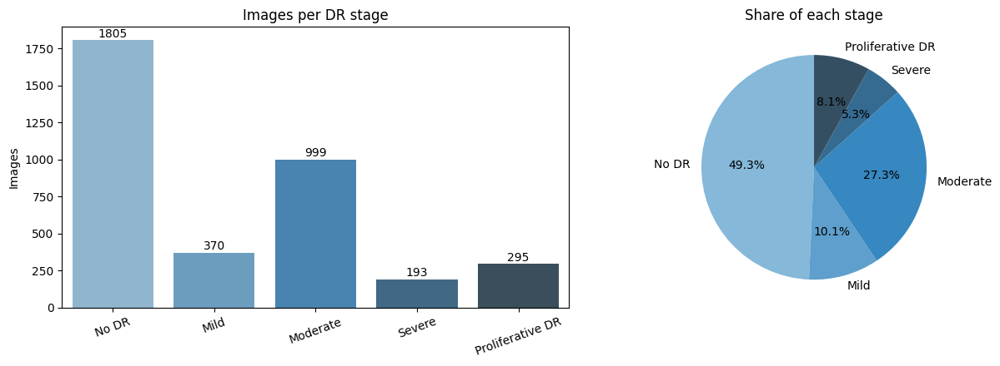

In [8]:
counts = df['diagnosis'].value_counts().sort_index()
imbalance_ratio = counts.max() / counts.min()
RESULTS['imbalance_ratio'] = round(float(imbalance_ratio), 2)
print(pd.DataFrame({'count': counts.values, 'percent': (counts / counts.sum() * 100).round(1).values},
                   index=CLASS_NAMES))
print(f'Imbalance ratio (largest / smallest class): {imbalance_ratio:.1f} : 1')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=CLASS_NAMES, y=counts.values, ax=ax[0], palette='Blues_d')
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 20, str(v), ha='center')
ax[0].set_title('Images per DR stage'); ax[0].set_ylabel('Images'); ax[0].tick_params(axis='x', rotation=20)
ax[1].pie(counts.values, labels=CLASS_NAMES, autopct='%1.1f%%', startangle=90,
          colors=sns.color_palette('Blues_d', NUM_CLASSES))
ax[1].set_title('Share of each stage')
plt.tight_layout(); save_fig('01_class_distribution'); plt.show()

**Image property analysis.** The photographs were taken with different cameras, so resolution and brightness vary a lot. This function reads the size of every image (header only, so it is fast) and the mean brightness of a sample of images per class. This variation is the evidence that justifies standardising the images in Section 2.

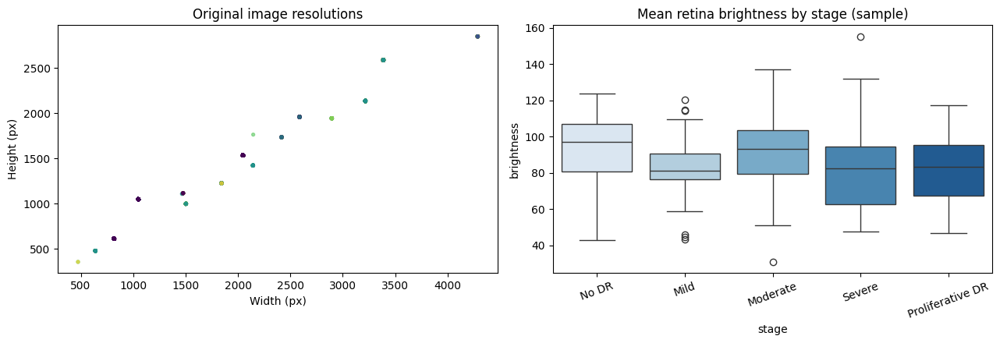

Resolution range: 474x358 to 4288x2848
Distinct resolutions: 17


In [9]:
def image_properties(paths, sample_for_brightness=60):
    # Width/height from the file header (no full decode), brightness from a downsized decode
    sizes = [Image.open(p).size for p in paths]
    rng = np.random.default_rng(SEED)
    sample = rng.choice(len(paths), size=min(sample_for_brightness, len(paths)), replace=False)
    bright = {}
    for i in sample:
        img = cv2.imread(paths[i], cv2.IMREAD_REDUCED_GRAYSCALE_4)
        bright[i] = float(img[img > 10].mean())   # ignore the black background
    return sizes, bright

sizes, _ = image_properties(df['path'].tolist(), sample_for_brightness=1)
df['width'] = [s[0] for s in sizes]
df['height'] = [s[1] for s in sizes]

bright_rows = []
for cls in range(NUM_CLASSES):
    sub = df[df['diagnosis'] == cls]['path'].tolist()
    _, b = image_properties(sub, sample_for_brightness=60)
    bright_rows += [{'stage': CLASS_NAMES[cls], 'brightness': v} for v in b.values()]
bright_df = pd.DataFrame(bright_rows)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(df['width'], df['height'], c=df['diagnosis'], cmap='viridis', s=8, alpha=0.6)
ax[0].set_xlabel('Width (px)'); ax[0].set_ylabel('Height (px)'); ax[0].set_title('Original image resolutions')
sns.boxplot(data=bright_df, x='stage', y='brightness', ax=ax[1], palette='Blues')
ax[1].set_title('Mean retina brightness by stage (sample)'); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); save_fig('02_image_properties'); plt.show()

print(f"Resolution range: {df['width'].min()}x{df['height'].min()} to {df['width'].max()}x{df['height'].max()}")
print('Distinct resolutions:', df[['width', 'height']].drop_duplicates().shape[0])

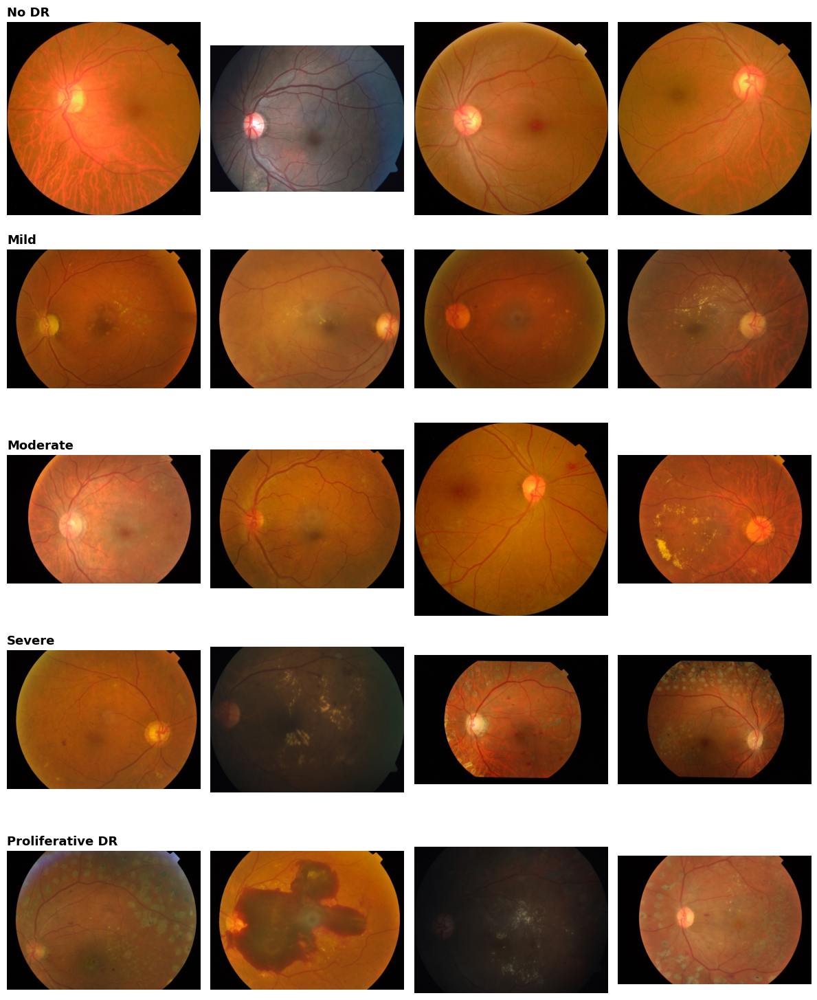

In [10]:
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(12, 15))
for cls in range(NUM_CLASSES):
    paths = df[df['diagnosis'] == cls]['path'].sample(4, random_state=SEED).tolist()
    for j, p in enumerate(paths):
        axes[cls, j].imshow(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB))
        axes[cls, j].axis('off')
    axes[cls, 0].set_title(CLASS_NAMES[cls], loc='left', fontsize=13, fontweight='bold')
plt.tight_layout(); save_fig('03_samples_per_stage'); plt.show()

## 2. Data preprocessing

The pipeline is built from small single-purpose functions so that each step can be shown, justified and tested on its own:

**load → crop black border → pad to square → resize → denoise → CLAHE contrast enhancement → edge enhancement → circular mask**

Every step is applied per image with fixed parameters. Nothing is fitted on the dataset, so preprocessing cannot leak information from the test set.

`load_rgb` reads an image from disk and converts OpenCV's default BGR channel order to RGB.

In [11]:
def load_rgb(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f'Could not read image: {path}')
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

`crop_dark_border` removes the black area around the retina by finding the bounding box of all pixels brighter than a small threshold. This makes the retina, not the background, fill the image.

In [12]:
def crop_dark_border(img, tol=10):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    coords = cv2.findNonZero((gray > tol).astype(np.uint8))
    if coords is None:          # completely dark image - leave it unchanged
        return img
    x, y, w, h = cv2.boundingRect(coords)
    return img[y:y + h, x:x + w]

`pad_to_square` adds black borders so the crop becomes square before resizing. Without this, retinas that are clipped at the top and bottom would be stretched into ovals, distorting the shapes of lesions.

In [13]:
def pad_to_square(img):
    h, w = img.shape[:2]
    size = max(h, w)
    top, left = (size - h) // 2, (size - w) // 2
    return cv2.copyMakeBorder(img, top, size - h - top, left, size - w - left,
                              cv2.BORDER_CONSTANT, value=(0, 0, 0))

`denoise` applies a **bilateral filter**, which smooths sensor noise while preserving edges. Ordinary Gaussian blur would also blur vessel boundaries and small microaneurysms, which are exactly the features the model needs.

In [14]:
def denoise(img):
    return cv2.bilateralFilter(img, d=5, sigmaColor=40, sigmaSpace=40)

`apply_clahe` performs **Contrast Limited Adaptive Histogram Equalisation** on the lightness channel of the LAB colour space. It boosts local contrast tile by tile, making faint haemorrhages and exudates visible, while the clip limit prevents noise from being over-amplified. Working only on lightness keeps the original colour information (red lesions, yellow exudates) intact.

In [15]:
def apply_clahe(img, clip_limit=2.0, tile=8):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile, tile)).apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)

`edge_enhance` applies **unsharp masking**: it subtracts a blurred copy from the image to sharpen edges. This satisfies the brief's *edge enhancement* requirement and makes vessel borders and lesion outlines crisper.

In [16]:
def edge_enhance(img, amount=0.6, sigma=3):
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    return cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)

`ben_graham` is an **alternative** preprocessing method from the winner of the 2015 Kaggle DR competition. It subtracts the local average colour to remove lighting differences between cameras. It is included for the comparison figure and can be selected with `CONFIG['PREPROCESS_MODE'] = 'ben_graham'`.

In [17]:
def ben_graham(img, sigma=None):
    sigma = sigma or img.shape[0] / 30
    return cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), sigma), -4, 128)

`apply_circular_mask` sets everything outside the circular field of view to black. Earlier steps (sharpening, Ben Graham) can create artefacts at the border, and the mask stops the model from learning from them.

In [18]:
def apply_circular_mask(img, scale=0.96):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), np.uint8)
    cv2.circle(mask, (w // 2, h // 2), int(min(h, w) / 2 * scale), 255, -1)
    return cv2.bitwise_and(img, img, mask=mask)

`preprocess_image` chains the steps above into the complete pipeline. It accepts **either a file path or an image array**, so exactly the same code is used for training, evaluation and live uploads in the Gradio app. This guarantees the model always sees identically processed images.

In [19]:
def preprocess_image(src, size=IMG_SIZE, mode=None):
    mode = mode or CONFIG['PREPROCESS_MODE']
    img = load_rgb(src) if isinstance(src, str) else np.ascontiguousarray(src[..., :3])
    img = pad_to_square(crop_dark_border(img))
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    if mode == 'clahe_edge':
        img = edge_enhance(apply_clahe(denoise(img)))
    elif mode == 'ben_graham':
        img = ben_graham(img)
    elif mode != 'raw':
        raise ValueError(f'Unknown preprocessing mode: {mode}')
    return apply_circular_mask(img)

**Step-by-step visual evidence.** Two images are shown at every stage of the pipeline, plus the Ben Graham alternative and a Canny edge map that highlights the vessel structure the model can use.

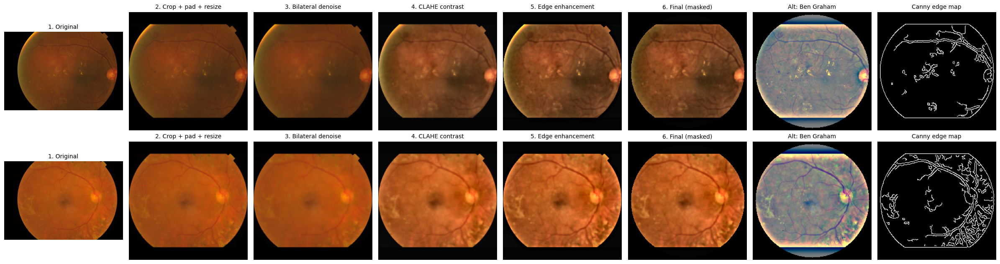

In [20]:
def show_pipeline(path, axes):
    raw = load_rgb(path)
    cropped = cv2.resize(pad_to_square(crop_dark_border(raw)), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    den = denoise(cropped)
    clahe = apply_clahe(den)
    edge = edge_enhance(clahe)
    final = apply_circular_mask(edge)
    bg = apply_circular_mask(ben_graham(cropped))
    canny = cv2.Canny(cv2.cvtColor(final, cv2.COLOR_RGB2GRAY), 40, 110)
    steps = [(raw, '1. Original'), (cropped, '2. Crop + pad + resize'), (den, '3. Bilateral denoise'),
             (clahe, '4. CLAHE contrast'), (edge, '5. Edge enhancement'), (final, '6. Final (masked)'),
             (bg, 'Alt: Ben Graham'), (canny, 'Canny edge map')]
    for ax, (im, title) in zip(axes, steps):
        ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
        ax.set_title(title, fontsize=10); ax.axis('off')

demo_paths = [df[df['diagnosis'] == 2]['path'].iloc[0], df[df['diagnosis'] == 4]['path'].iloc[0]]
fig, axes = plt.subplots(2, 8, figsize=(24, 6.5))
for row, p in enumerate(demo_paths):
    show_pipeline(p, axes[row])
plt.tight_layout(); save_fig('04_preprocessing_pipeline'); plt.show()

**Quantitative image-quality check.** Instead of only claiming that preprocessing improves the images, this measures three standard quality metrics inside the retina on 150 images, before and after preprocessing:
- **RMS contrast**: standard deviation of intensity (higher = more contrast)
- **Shannon entropy**: how much information the intensity histogram carries
- **Laplacian variance**: a standard sharpness / edge-strength measure

                            Before   After  Change (%)
RMS contrast                 17.21   22.11        28.4
Entropy (bits)                5.79    6.31         9.1
Sharpness (Laplacian var.)  364.40  645.10        77.0


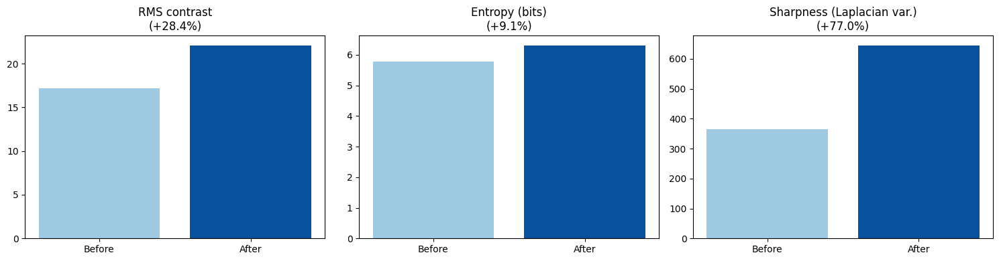

In [21]:
def quality_metrics(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    roi = gray[gray > 5].astype(np.float32)               # retina pixels only
    hist = np.bincount(roi.astype(np.uint8), minlength=256) / max(len(roi), 1)
    hist = hist[hist > 0]
    return {'RMS contrast': roi.std(),
            'Entropy (bits)': float(-(hist * np.log2(hist)).sum()),
            'Sharpness (Laplacian var.)': cv2.Laplacian(gray, cv2.CV_64F).var()}

sample_paths = df['path'].sample(150, random_state=SEED).tolist()
before = pd.DataFrame([quality_metrics(preprocess_image(p, mode='raw')) for p in sample_paths])
after = pd.DataFrame([quality_metrics(preprocess_image(p)) for p in sample_paths])

quality = pd.DataFrame({'Before': before.mean(), 'After': after.mean()})
quality['Change (%)'] = ((quality['After'] - quality['Before']) / quality['Before'] * 100).round(1)
print(quality.round(2))
RESULTS['preprocessing_quality_change_pct'] = quality['Change (%)'].to_dict()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, quality.index):
    ax.bar(['Before', 'After'], quality.loc[metric, ['Before', 'After']], color=['#9ecae1', '#08519c'])
    ax.set_title(f"{metric}\n({quality.loc[metric, 'Change (%)']:+.1f}%)")
plt.tight_layout(); save_fig('05_preprocessing_quality'); plt.show()

**Preprocessing cache (extra, efficiency).** Preprocessing all 3,662 full-resolution photos takes a few minutes, so it is done **once**, in parallel threads, and the results are kept in memory as a `uint8` array (~550 MB). Training then reads ready-made images instead of re-running OpenCV every epoch, which makes each epoch many times faster than decoding images on the fly.

In [22]:
def build_cache(paths, size=IMG_SIZE, mode=None):
    mode = mode or CONFIG['PREPROCESS_MODE']
    cache_file = f'{CACHE_DIR}/X_{mode}_{size}.npy'
    if os.path.exists(cache_file):
        print('Loading cached images from', cache_file)
        return np.load(cache_file)
    start = time.time()
    images = Parallel(n_jobs=-1, prefer='threads')(
        delayed(preprocess_image)(p, size, mode) for p in paths)
    X = np.stack(images).astype(np.uint8)
    np.save(cache_file, X)
    print(f'Preprocessed {len(X)} images in {time.time() - start:.0f}s -> {X.nbytes / 1e6:.0f} MB')
    return X

X_all = build_cache(df['path'].tolist())
y_all = df['diagnosis'].values
print('Image array:', X_all.shape, X_all.dtype, '| pixel range:', X_all.min(), '-', X_all.max())

Preprocessed 3662 images in 243s -> 551 MB
Image array: (3662, 224, 224, 3) uint8 | pixel range: 0 - 255


## 3. Train / validation / test split

The data is split **70 / 15 / 15**, stratified by stage, so every subset keeps the same class proportions.
- **Train**: used to fit the weights
- **Validation**: used for every decision (early stopping, choosing the backbone and hyperparameters, accepting TTA, choosing thresholds)
- **Test**: touched **only once**, for the final reported results

The split happens **before** any oversampling, so no duplicated image can appear in both training and test data.

                  Train  Validation  Test
No DR              1263         271   271
Mild                259          55    56
Moderate            699         150   150
Severe              135          29    29
Proliferative DR    207          44    44
Total              2563         549   550


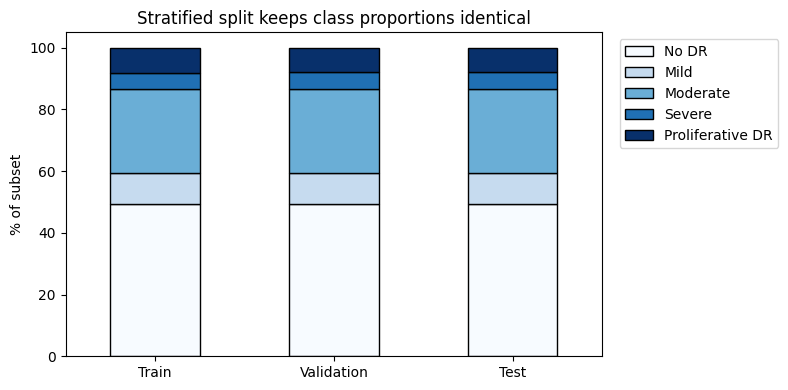

In [23]:
idx_all = np.arange(len(df))
train_idx, temp_idx = train_test_split(idx_all, test_size=0.30, stratify=y_all, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, stratify=y_all[temp_idx], random_state=SEED)
y_train, y_val, y_test = y_all[train_idx], y_all[val_idx], y_all[test_idx]

split_table = pd.DataFrame({name: np.bincount(y, minlength=NUM_CLASSES)
                            for name, y in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]},
                           index=CLASS_NAMES)
split_table.loc['Total'] = split_table.sum()
print(split_table)

(split_table.drop('Total') / split_table.drop('Total').sum() * 100).T.plot(
    kind='bar', stacked=True, figsize=(8, 4), colormap='Blues', edgecolor='black')
plt.ylabel('% of subset'); plt.title('Stratified split keeps class proportions identical')
plt.xticks(rotation=0); plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); save_fig('06_split_distribution'); plt.show()

## 4. Data augmentation & dataset balancing

**Augmentation** creates a new random variation of every training image each time it is seen, which increases diversity and reduces overfitting. Each transform is chosen to match real variation in fundus photography:

| Transform | Setting | Justification |
|---|---|---|
| Horizontal + vertical flip | random | Left/right eyes are mirror images; the camera can be orientated either way |
| Rotation | up to ±180° | A circular retina has no fixed "up", so the label does not depend on rotation |
| Zoom | ±10% | Simulates different camera distances and fields of view |
| Brightness | ±10% | Simulates different flash strengths and exposures |
| Contrast | ±10% | Simulates different camera sensors |

Transforms are deliberately **mild** in intensity. Strong colour or blur changes could erase tiny microaneurysms and change the true stage.

The augmentation runs on the GPU as Keras preprocessing layers, inside the `tf.data` pipeline, and **only on training images**.

In [24]:
def build_augmenter():
    return keras.Sequential([
        layers.RandomFlip('horizontal_and_vertical', seed=SEED),
        layers.RandomRotation(0.5, fill_mode='constant', fill_value=0.0, seed=SEED),
        layers.RandomZoom(0.1, fill_mode='constant', fill_value=0.0, seed=SEED),
        layers.RandomBrightness(0.1, value_range=(0, 255), seed=SEED),
        layers.RandomContrast(0.1, seed=SEED),
    ], name='augmentation')

augmenter = build_augmenter()

I0000 00:00:1790846554.518535      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790846554.521451      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Apply the augmenter eight times to the same image to confirm the transforms are realistic: the retina is still clearly recognisable and no diagnostic detail is destroyed.

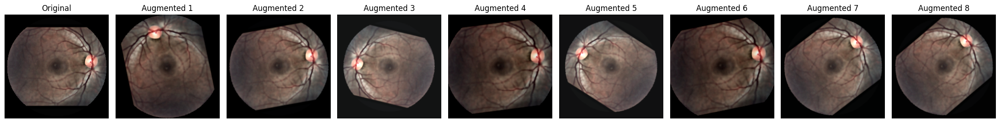

In [25]:
sample_img = X_all[train_idx[0]].astype(np.float32)
fig, axes = plt.subplots(1, 9, figsize=(22, 3))
axes[0].imshow(sample_img.astype(np.uint8)); axes[0].set_title('Original'); axes[0].axis('off')
for i, ax in enumerate(axes[1:], 1):
    aug = tf.clip_by_value(augmenter(sample_img[None], training=True), 0, 255)[0].numpy()
    ax.imshow(aug.astype(np.uint8)); ax.set_title(f'Augmented {i}'); ax.axis('off')
plt.tight_layout(); save_fig('07_augmentation_examples'); plt.show()

**Dataset balancing.** `balance_indices` **oversamples** each minority class (random duplication of training images) until it reaches at least `MIN_CLASS_RATIO` × the size of the largest class. Because augmentation is random, every duplicate is a different variation in each epoch, not an identical copy.

**Why partial (50%) balancing instead of full balancing or class weights:**
- With **no balancing**, the model learns to predict *No DR* for almost everything (49% "accuracy" for free).
- **Full balancing** repeats the 135 Severe images about 9 times. This encourages memorising them and distorts the model's sense of how common each stage really is, which lowers precision on the common classes.
- In an earlier version of this project, **heavy loss-based class weights** (up to 24×) made training unstable.

Raising every class to 50% of the majority is a middle ground. Only the **training** set is balanced; validation and test sets keep their real-world distribution so the reported metrics stay honest.

                  Before balancing  After balancing
No DR                         1263             1263
Mild                           259              631
Moderate                       699              699
Severe                         135              631
Proliferative DR               207              631


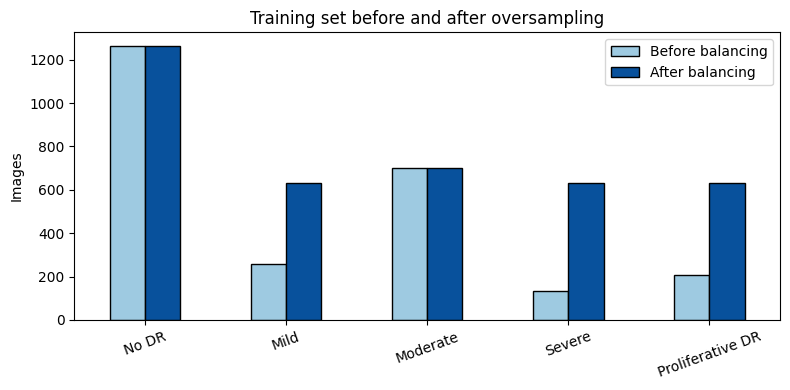

In [26]:
def balance_indices(indices, labels, min_ratio=0.5, seed=SEED):
    rng = np.random.default_rng(seed)
    target = int(np.bincount(labels).max() * min_ratio)
    out = []
    for cls in np.unique(labels):
        cls_idx = indices[labels == cls]
        if len(cls_idx) < target:
            extra = rng.choice(cls_idx, size=target - len(cls_idx), replace=True)
            cls_idx = np.concatenate([cls_idx, extra])
        out.append(cls_idx)
    out = np.concatenate(out)
    rng.shuffle(out)
    return out

train_bal_idx = balance_indices(train_idx, y_train, CONFIG['MIN_CLASS_RATIO'])
y_train_bal = y_all[train_bal_idx]

before_after = pd.DataFrame({'Before balancing': np.bincount(y_train, minlength=NUM_CLASSES),
                             'After balancing': np.bincount(y_train_bal, minlength=NUM_CLASSES)},
                            index=CLASS_NAMES)
print(before_after)
before_after.plot(kind='bar', figsize=(8, 4), color=['#9ecae1', '#08519c'], edgecolor='black')
plt.title('Training set before and after oversampling'); plt.ylabel('Images'); plt.xticks(rotation=20)
plt.tight_layout(); save_fig('08_balancing'); plt.show()

## 5. Efficient input pipeline (`tf.data`)

`make_dataset` turns an image array into a batched, prefetched `tf.data.Dataset`:
- **Training**: shuffle → batch → GPU augmentation → clip to [0, 255] → prefetch
- **Validation / test**: batch → prefetch (no augmentation, no shuffling)

**Important:** pixels are kept in the **raw [0, 255] range** and are **not** divided by 255. Keras's EfficientNet contains its own built-in rescaling and normalisation layers, and the other backbones get an explicit `Rescaling` layer inside the model (Section 6). Normalising here as well would shrink every pixel to almost zero and the network could not learn.

In [27]:
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(X, y, training=False, batch_size=CONFIG['BATCH_SIZE']):
    ds = tf.data.Dataset.from_tensor_slices((X, tf.one_hot(y, NUM_CLASSES)))
    if training:
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).map(lambda x, t: (tf.cast(x, tf.float32), t), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, t: (tf.clip_by_value(augmenter(x, training=True), 0.0, 255.0), t),
                    num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

X_train_bal = X_all[train_bal_idx]
X_val, X_test = X_all[val_idx], X_all[test_idx]

train_ds = make_dataset(X_train_bal, y_train_bal, training=True)
val_ds = make_dataset(X_val, y_val)
test_ds = make_dataset(X_test, y_test)

**Sanity check:** inspect one training batch to confirm the shapes, the label encoding and the expected [0, 255] pixel range, before spending GPU time on training.

In [28]:
xb, yb = next(iter(train_ds))
print('Batch images:', xb.shape, xb.dtype, '| labels:', yb.shape)
print(f'Pixel range: {float(tf.reduce_min(xb)):.1f} to {float(tf.reduce_max(xb)):.1f}  (expected 0-255)')
print('Classes in this batch:', np.bincount(np.argmax(yb, 1), minlength=NUM_CLASSES))
assert float(tf.reduce_max(xb)) > 2.0, 'Images look normalised to [0,1] - check the pipeline'

Batch images: (32, 224, 224, 3) <dtype: 'float32'> | labels: (32, 5)
Pixel range: 0.0 to 255.0  (expected 0-255)
Classes in this batch: [9 8 5 2 8]


## 6. CNN architecture & transfer learning

**Transfer learning** reuses a convolutional network already trained on the 1.2 million images of ImageNet. Its early layers have learned general features (edges, textures, blobs), which transfer well to retinal lesions. Starting from these weights is essential here: 2,563 training images are far too few to train a deep CNN from scratch.

`build_model` supports three backbones so they can be compared fairly:
| Backbone | Parameters | Why consider it |
|---|---|---|
| **EfficientNetB0** | 4.0 M | Compound-scaled; strong accuracy per parameter; widely used for APTOS |
| **ResNet50V2** | 23.6 M | Classic deep residual network, strong standard baseline |
| **MobileNetV2** | 2.3 M | Very light, suitable for mobile / edge screening devices |

**Classification head:** Global Average Pooling → BatchNorm → Dropout → Dense (ReLU) → Dropout → Dense (5, softmax). Global average pooling has no weights, which limits overfitting. Dropout adds regularisation.

The backbone is called with `training=False`, so its BatchNorm layers stay in inference mode even during fine-tuning. This is the recommended way to fine-tune pretrained networks with small batches.

In [29]:
BACKBONES = {
    # name: (constructor, input scaling required by that network)
    'EfficientNetB0': (keras.applications.EfficientNetB0, None),        # rescales internally
    'ResNet50V2':     (keras.applications.ResNet50V2, 'minus1_to_1'),
    'MobileNetV2':    (keras.applications.MobileNetV2, 'minus1_to_1'),
}

def build_model(backbone_name, dense_units=256, dropout=0.3):
    constructor, scaling = BACKBONES[backbone_name]
    backbone = constructor(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    backbone.trainable = False                       # phase 1: frozen feature extractor

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image')
    x = inputs
    if scaling == 'minus1_to_1':
        x = layers.Rescaling(1 / 127.5, offset=-1, name='scale_input')(x)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='head_bn')(x)
    x = layers.Dropout(dropout, name='head_dropout_1')(x)
    x = layers.Dense(dense_units, activation='relu', name='head_dense')(x)
    x = layers.Dropout(dropout / 2, name='head_dropout_2')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='stage_probs')(x)
    return keras.Model(inputs, outputs, name=f'DR_{backbone_name}'), backbone

`compile_model` uses the Adam optimiser with **categorical cross-entropy with label smoothing**. Label smoothing replaces the hard target 1.0 with 0.95, which stops the model from becoming over-confident on labels that are known to be noisy (grader disagreement between neighbouring stages).

`jit_compile=False` disables XLA compilation. This avoids slow first-epoch compilation and the "Delay kernel timed out" log spam seen on Kaggle T4 GPUs.

In [30]:
def compile_model(model, lr):
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss=keras.losses.CategoricalCrossentropy(label_smoothing=CONFIG['LABEL_SMOOTHING']),
                  metrics=['accuracy'],
                  jit_compile=False)
    return model

**Custom model-selection metric (extra).** On an imbalanced validation set, validation loss and accuracy can look best at the very epoch where the model predicts only the majority class. `ClinicalMetricsCallback` therefore calculates, after every epoch:
- **Macro F1**: averages F1 over the 5 stages equally, so rare stages count as much as common ones
- **Quadratic weighted kappa (QWK)**: agreement with the clinicians that penalises far-off errors (0→4) more than near ones (2→3). QWK was the official APTOS competition metric.
- **`val_score` = (macro F1 + QWK) / 2**: used for early stopping, learning-rate scheduling and checkpointing. A model that collapses to one class scores 0 QWK, so it can never be selected.

In [31]:
def clinical_scores(y_true, y_pred):
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    qwk = 0.0 if np.isnan(qwk) else qwk
    return f1, qwk, (f1 + qwk) / 2

class ClinicalMetricsCallback(keras.callbacks.Callback):
    def __init__(self, val_ds, y_val):
        super().__init__()
        self.val_ds, self.y_val = val_ds, y_val

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        y_pred = self.model.predict(self.val_ds, verbose=0).argmax(1)
        f1, qwk, score = clinical_scores(self.y_val, y_pred)
        logs.update({'val_macro_f1': f1, 'val_qwk': qwk, 'val_score': score})
        print(f'  -> val_macro_f1={f1:.4f}  val_qwk={qwk:.4f}  val_score={score:.4f}')

`get_callbacks` assembles the full training strategy:
- **ClinicalMetricsCallback** (must come first, so the other callbacks can see `val_score`)
- **EarlyStopping**: stops when `val_score` stops improving, preventing overfitting and wasted GPU time
- **ReduceLROnPlateau**: lowers the learning rate when progress stalls, so the model can settle into a better minimum
- **ModelCheckpoint**: saves the weights of the best epoch to disk
- **CSVLogger**: writes a per-epoch log for the report appendix

In [32]:
def get_callbacks(tag, patience=6, min_lr=1e-7):
    return [
        ClinicalMetricsCallback(val_ds, y_val),
        keras.callbacks.EarlyStopping(monitor='val_score', mode='max', patience=patience, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_score', mode='max', factor=0.3,
                                          patience=max(2, patience // 2), min_lr=min_lr, verbose=1),
        keras.callbacks.ModelCheckpoint(f'{OUT_DIR}/best_{tag}.weights.h5', monitor='val_score',
                                        mode='max', save_best_only=True, save_weights_only=True),
        keras.callbacks.CSVLogger(f'{OUT_DIR}/training_log_{tag}.csv'),
    ]

`run_quick_experiment` trains a model with a **frozen backbone** for a few epochs and returns its best validation scores. It is used for the backbone comparison and the hyperparameter search below. Every candidate gets exactly the same data, epochs and evaluation, so the comparison is fair. Memory is released after each run.

In [33]:
def run_quick_experiment(backbone_name, lr, dense_units, dropout, epochs):
    model, _ = build_model(backbone_name, dense_units, dropout)
    compile_model(model, lr)
    start = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=0,
                     callbacks=[ClinicalMetricsCallback(val_ds, y_val)])
    h = hist.history
    best = int(np.argmax(h['val_score']))
    result = {'backbone': backbone_name, 'lr': lr, 'dense_units': dense_units, 'dropout': dropout,
              'params_M': round(model.count_params() / 1e6, 2), 'minutes': round((time.time() - start) / 60, 1),
              'val_accuracy': h['val_accuracy'][best], 'val_macro_f1': h['val_macro_f1'][best],
              'val_qwk': h['val_qwk'][best], 'val_score': h['val_score'][best]}
    del model; gc.collect()
    return result

### Experiment A: backbone comparison
EfficientNetB0, ResNet50V2 and MobileNetV2 are each trained under identical conditions with a frozen backbone, and compared on validation score, accuracy, size and training time. The best backbone is selected **automatically** for the final model. This gives the architecture choice an evidence-based justification instead of picking one arbitrarily.

Training EfficientNetB0 ...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


E0000 00:00:1790846711.690752      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DR_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  -> val_macro_f1=0.4104  val_qwk=0.7429  val_score=0.5766
  -> val_macro_f1=0.4891  val_qwk=0.7897  val_score=0.6394
  -> val_macro_f1=0.5447  val_qwk=0.7780  val_score=0.6614
  -> val_macro_f1=0.5541  val_qwk=0.7908  val_score=0.6724
  -> val_macro_f1=0.5089  val_qwk=0.7872  val_score=0.6480
Training ResNet50V2 ...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  -> val_macro_f1=0.4100  val_qwk=0.6480  val_score=0.5290
  -> val_macro_f1=0.4763  val_qwk=0.7677  val_score=0.6220
  -> val_macro_f1=0.5307  val_qwk=0.7625  val_score=0.6466
  -> val_macro_f1=0.5020  val_qwk=0.7448  val_score=0.6234
  -> val_macro_f1=0.5180  val_qwk=0.7710  val_score=0.6445
Training MobileNetV2 ...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  -> val_macro_f1=0.3977  val_qwk=0.5975  val_score=0.4976
  -> val_macro_f1=0.4786  val_qwk=0.7209  val_score=0.5997
  -> val_macro_f1=0.5038  val_qwk=0.6921  val_score=0.5979
  -> val_macro_f1=0.5043  val_qwk=0.7342  val_score=0.6192
  -> val_macro_f1=0.4833 

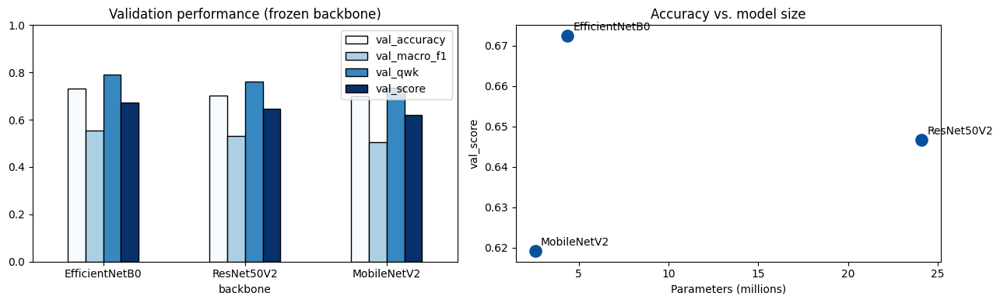

Selected backbone: EfficientNetB0


In [34]:
if CONFIG['RUN_BACKBONE_COMPARISON']:
    backbone_results = []
    for name in BACKBONES:
        print(f'Training {name} ...')
        backbone_results.append(run_quick_experiment(name, CONFIG['HEAD_LR'], CONFIG['DENSE_UNITS'],
                                                     CONFIG['DROPOUT'], CONFIG['COMPARE_EPOCHS']))
    backbone_df = pd.DataFrame(backbone_results).sort_values('val_score', ascending=False)
    backbone_df.to_csv(f'{OUT_DIR}/experiment_backbones.csv', index=False)
    print(backbone_df[['backbone', 'params_M', 'minutes', 'val_accuracy', 'val_macro_f1', 'val_qwk', 'val_score']].round(4))

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    backbone_df.set_index('backbone')[['val_accuracy', 'val_macro_f1', 'val_qwk', 'val_score']].plot(
        kind='bar', ax=ax[0], colormap='Blues', edgecolor='black')
    ax[0].set_title('Validation performance (frozen backbone)'); ax[0].set_ylim(0, 1); ax[0].tick_params(axis='x', rotation=0)
    ax[1].scatter(backbone_df['params_M'], backbone_df['val_score'], s=120, c='#08519c')
    for _, r in backbone_df.iterrows():
        ax[1].annotate(r['backbone'], (r['params_M'], r['val_score']), textcoords='offset points', xytext=(5, 5))
    ax[1].set_xlabel('Parameters (millions)'); ax[1].set_ylabel('val_score'); ax[1].set_title('Accuracy vs. model size')
    plt.tight_layout(); save_fig('09_backbone_comparison'); plt.show()

    CONFIG['BACKBONE'] = backbone_df.iloc[0]['backbone']
    RESULTS['backbone_comparison'] = backbone_df.round(4).to_dict('records')
print('Selected backbone:', CONFIG['BACKBONE'])

### Experiment B: hyperparameter search 
A small grid search on the selected backbone, over **head learning rate** {1e-3, 3e-4} × **dense units** {128, 256}. The best configuration on the validation set is used for final training.

lr=0.001, dense_units=128 ...


E0000 00:00:1790847198.050148      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DR_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  -> val_macro_f1=0.4566  val_qwk=0.7214  val_score=0.5890
  -> val_macro_f1=0.4862  val_qwk=0.7294  val_score=0.6078
  -> val_macro_f1=0.5376  val_qwk=0.7926  val_score=0.6651
  -> val_macro_f1=0.5145  val_qwk=0.7949  val_score=0.6547
lr=0.001, dense_units=256 ...


E0000 00:00:1790847299.520640      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DR_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  -> val_macro_f1=0.3718  val_qwk=0.6378  val_score=0.5048
  -> val_macro_f1=0.4453  val_qwk=0.7610  val_score=0.6032
  -> val_macro_f1=0.4940  val_qwk=0.7670  val_score=0.6305
  -> val_macro_f1=0.5350  val_qwk=0.8014  val_score=0.6682
lr=0.0003, dense_units=128 ...


E0000 00:00:1790847400.025795      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DR_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  -> val_macro_f1=0.4269  val_qwk=0.7281  val_score=0.5775
  -> val_macro_f1=0.4802  val_qwk=0.7327  val_score=0.6065
  -> val_macro_f1=0.5278  val_qwk=0.7807  val_score=0.6542
  -> val_macro_f1=0.5001  val_qwk=0.7541  val_score=0.6271
lr=0.0003, dense_units=256 ...


E0000 00:00:1790847501.564351      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DR_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  -> val_macro_f1=0.5180  val_qwk=0.7453  val_score=0.6317
  -> val_macro_f1=0.5303  val_qwk=0.7969  val_score=0.6636
  -> val_macro_f1=0.5016  val_qwk=0.7884  val_score=0.6450
  -> val_macro_f1=0.5267  val_qwk=0.8016  val_score=0.6641
       lr  dense_units  val_accuracy  val_macro_f1  val_qwk  val_score
1  0.0010          256        0.7286        0.5350   0.8014     0.6682
0  0.0010          128        0.7523        0.5376   0.7926     0.6651
3  0.0003          256        0.7359        0.5267   0.8016     0.6641
2  0.0003          128        0.7286        0.5278   0.7807     0.6542


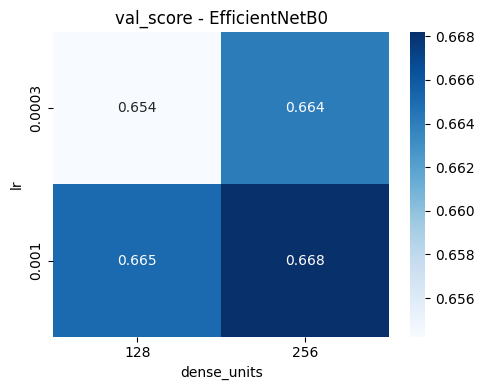

Final configuration: backbone=EfficientNetB0, head_lr=0.001, dense_units=256


In [35]:
if CONFIG['RUN_HPARAM_SEARCH']:
    search_results = []
    for lr in [1e-3, 3e-4]:
        for units in [128, 256]:
            print(f'lr={lr}, dense_units={units} ...')
            search_results.append(run_quick_experiment(CONFIG['BACKBONE'], lr, units,
                                                       CONFIG['DROPOUT'], CONFIG['SEARCH_EPOCHS']))
    search_df = pd.DataFrame(search_results).sort_values('val_score', ascending=False)
    search_df.to_csv(f'{OUT_DIR}/experiment_hparams.csv', index=False)
    print(search_df[['lr', 'dense_units', 'val_accuracy', 'val_macro_f1', 'val_qwk', 'val_score']].round(4))

    plt.figure(figsize=(5, 4))
    sns.heatmap(search_df.pivot(index='lr', columns='dense_units', values='val_score'),
                annot=True, fmt='.3f', cmap='Blues')
    plt.title(f"val_score - {CONFIG['BACKBONE']}"); plt.tight_layout(); save_fig('10_hparam_search'); plt.show()

    CONFIG['HEAD_LR'] = float(search_df.iloc[0]['lr'])
    CONFIG['DENSE_UNITS'] = int(search_df.iloc[0]['dense_units'])
    RESULTS['hparam_search'] = search_df.round(4).to_dict('records')
print(f"Final configuration: backbone={CONFIG['BACKBONE']}, head_lr={CONFIG['HEAD_LR']}, dense_units={CONFIG['DENSE_UNITS']}")

## 7. Final model training: two-phase transfer learning 

**Phase 1 – feature extraction.** The pretrained backbone is frozen and only the new head is trained, at a relatively high learning rate. The randomly initialised head first learns to use the ImageNet features, without sending large, noisy gradients into the pretrained weights.

**Phase 2 – fine-tuning.** The backbone's convolutional layers are unfrozen and the whole network is trained at a **much lower learning rate** (5e-5). The pretrained features adapt gradually to retinal images. BatchNorm layers stay frozen to keep their ImageNet statistics stable.

Build the final model with the selected backbone and hyperparameters, and print its architecture summary.

In [36]:
keras.utils.set_random_seed(SEED)
model, backbone = build_model(CONFIG['BACKBONE'], CONFIG['DENSE_UNITS'], CONFIG['DROPOUT'])
compile_model(model, CONFIG['HEAD_LR'])
model.summary()

Model: "DR_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)    │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_1 (Dropout)        │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_2 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage_probs (Dense)             │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,912 (16.72 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

**Phase 1:** train the classification head with the backbone frozen. Afterwards, the best checkpoint (by `val_score`) is reloaded explicitly, so Phase 2 always starts from the best Phase 1 weights.

In [37]:
history1 = model.fit(train_ds, validation_data=val_ds, epochs=CONFIG['PHASE1_EPOCHS'],
                     callbacks=get_callbacks('phase1', patience=4))
model.load_weights(f'{OUT_DIR}/best_phase1.weights.h5')

Epoch 1/8


E0000 00:00:1790847657.020427      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DR_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


120/121 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.5430 - loss: 1.4858  -> val_macro_f1=0.4408  val_qwk=0.6899  val_score=0.5654
121/121 ━━━━━━━━━━━━━━━━━━━━ 40s 237ms/step - accuracy: 0.5979 - loss: 1.2879 - val_accuracy: 0.6175 - val_loss: 1.0564 - val_macro_f1: 0.4408 - val_qwk: 0.6899 - val_score: 0.5654 - learning_rate: 0.0010
Epoch 2/8
120/121 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.6468 - loss: 1.0454  -> val_macro_f1=0.5546  val_qwk=0.8017  val_score=0.6781
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 172ms/step - accuracy: 0.6698 - loss: 1.0095 - val_accuracy: 0.7541 - val_loss: 0.8156 - val_macro_f1: 0.5546 - val_qwk: 0.8017 - val_score: 0.6781 - learning_rate: 0.0010
Epoch 3/8
120/121 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.6889 - loss: 0.9270  -> val_macro_f1=0.5192  val_qwk=0.7696  val_score=0.6444
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 167ms/step - accuracy: 0.6866 - loss: 0.9446 - val_accuracy: 0.7450 - val_loss: 0.8322 - val_macro_f1: 0.5192 - val_qwk: 0.7696 - va

`unfreeze_backbone` makes the top `fraction` of backbone layers trainable but keeps every BatchNormalization layer frozen. It then reports how many parameters became trainable, which is useful evidence for the report.

In [38]:
def unfreeze_backbone(backbone, fraction=1.0):
    backbone.trainable = True
    cutoff = int(len(backbone.layers) * (1 - fraction))
    for i, layer in enumerate(backbone.layers):
        if i < cutoff or isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    trainable = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
    print(f'Trainable parameters after unfreezing: {trainable:,} of {model.count_params():,}')

unfreeze_backbone(backbone, CONFIG['FINETUNE_FRACTION'])
compile_model(model, CONFIG['FINETUNE_LR'])     # must recompile after changing trainable flags

Trainable parameters after unfreezing: 4,297,313 of 4,383,912


<Functional name=DR_EfficientNetB0, built=True>

**Phase 2:** fine-tune the whole network at the low learning rate, then reload the best fine-tuned checkpoint.

In [39]:
history2 = model.fit(train_ds, validation_data=val_ds, epochs=CONFIG['PHASE2_EPOCHS'],
                     callbacks=get_callbacks('phase2', patience=7, min_lr=1e-8))
model.load_weights(f'{OUT_DIR}/best_phase2.weights.h5')

val_pred = model.predict(val_ds, verbose=0).argmax(1)
print('Best model on validation -> accuracy: %.4f | macro F1: %.4f | QWK: %.4f | score: %.4f'
      % ((accuracy_score(y_val, val_pred),) + clinical_scores(y_val, val_pred)))

Epoch 1/25


E0000 00:00:1790847909.367496      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DR_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.7682 - loss: 0.7567  -> val_macro_f1=0.5426  val_qwk=0.7745  val_score=0.6585
121/121 ━━━━━━━━━━━━━━━━━━━━ 65s 330ms/step - accuracy: 0.7782 - loss: 0.7344 - val_accuracy: 0.7523 - val_loss: 0.9259 - val_macro_f1: 0.5426 - val_qwk: 0.7745 - val_score: 0.6585 - learning_rate: 5.0000e-05
Epoch 2/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.8153 - loss: 0.6690  -> val_macro_f1=0.5419  val_qwk=0.8012  val_score=0.6715
121/121 ━━━━━━━━━━━━━━━━━━━━ 33s 265ms/step - accuracy: 0.8158 - loss: 0.6772 - val_accuracy: 0.7741 - val_loss: 0.8951 - val_macro_f1: 0.5419 - val_qwk: 0.8012 - val_score: 0.6715 - learning_rate: 5.0000e-05
Epoch 3/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.8266 - loss: 0.6322  -> val_macro_f1=0.5501  val_qwk=0.8425  val_score=0.6963
121/121 ━━━━━━━━━━━━━━━━━━━━ 33s 264ms/step - accuracy: 0.8228 - loss: 0.6438 - val_accuracy: 0.7596 - val_loss: 0.7883 - val_macro_f1: 0.5501 - val_qwk: 0

## 8. Model evaluation & performance analysis

`plot_training_history` joins both training phases into one timeline and plots accuracy, loss, the clinical validation metrics and the learning rate. A dashed line marks where fine-tuning starts.

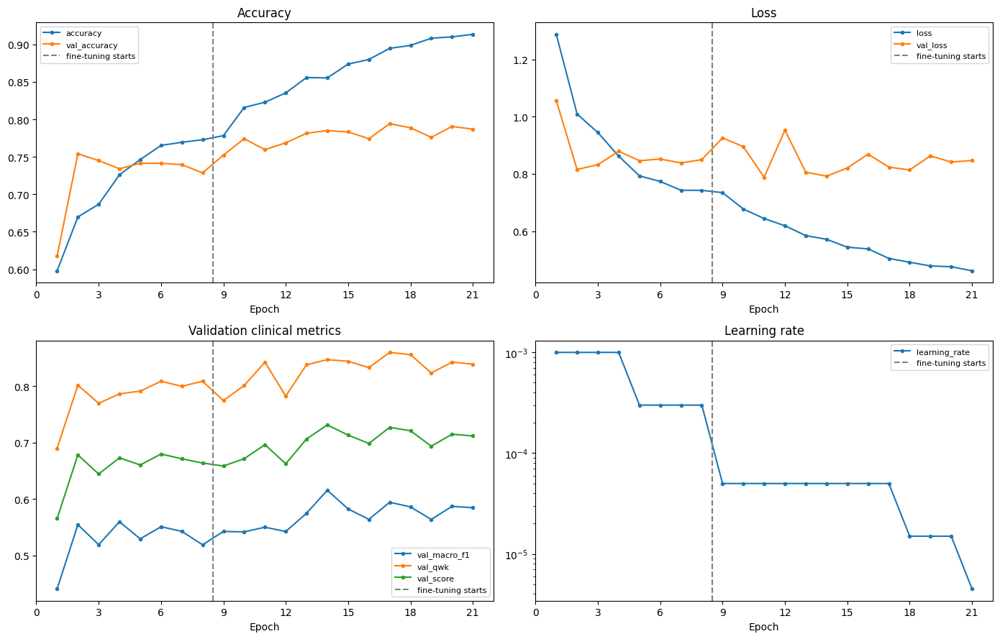

In [40]:
def plot_training_history(h1, h2):
    def series(key):
        return list(h1.history.get(key, [])) + list(h2.history.get(key, []))
    split = len(h1.history['loss'])
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    panels = [(['accuracy', 'val_accuracy'], 'Accuracy'), (['loss', 'val_loss'], 'Loss'),
              (['val_macro_f1', 'val_qwk', 'val_score'], 'Validation clinical metrics'),
              (['learning_rate'], 'Learning rate')]
    for ax, (keys, title) in zip(axes.flat, panels):
        for k in keys:
            if series(k):
                ax.plot(range(1, len(series(k)) + 1), series(k), marker='o', ms=3, label=k)
        ax.axvline(split + 0.5, color='grey', ls='--', label='fine-tuning starts')
        ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        if title == 'Learning rate':
            ax.set_yscale('log')
    plt.tight_layout(); save_fig('11_training_curves'); plt.show()

plot_training_history(history1, history2)

`predict_proba` returns class probabilities. With `tta=True` it uses **test-time augmentation **: it averages the predictions for the original image and its horizontal, vertical and double flips. Flipping does not change the stage, so averaging reduces variance.

TTA is accepted **only if it improves the validation score**. The test set never influences the decision, which avoids test-set leakage.

In [41]:
def predict_proba(m, X, tta=False, batch_size=64):
    X = X.astype(np.float32)
    variants = [X] if not tta else [X, X[:, :, ::-1], X[:, ::-1, :], X[:, ::-1, ::-1]]
    variants = [np.ascontiguousarray(v) for v in variants]
    return np.mean([m.predict(v, batch_size=batch_size, verbose=0) for v in variants], axis=0)

val_probs_plain = predict_proba(model, X_val)
val_probs_tta = predict_proba(model, X_val, tta=True)
score_plain = clinical_scores(y_val, val_probs_plain.argmax(1))[2]
score_tta = clinical_scores(y_val, val_probs_tta.argmax(1))[2]
USE_TTA = score_tta > score_plain
print(f'Validation score without TTA: {score_plain:.4f} | with TTA: {score_tta:.4f} -> use TTA: {USE_TTA}')

test_probs_plain = predict_proba(model, X_test)
test_probs = predict_proba(model, X_test, tta=True) if USE_TTA else test_probs_plain
val_probs = val_probs_tta if USE_TTA else val_probs_plain
test_pred = test_probs.argmax(1)

Validation score without TTA: 0.7313 | with TTA: 0.7333 -> use TTA: True


`evaluate_predictions` computes the full set of metrics on the **held-out test set**: accuracy, balanced accuracy, precision, recall, macro and weighted F1, QWK and multi-class ROC-AUC. It also prints the per-class classification report. Plain and TTA predictions are compared side by side.

In [42]:
def evaluate_predictions(y_true, probs, label):
    y_pred = probs.argmax(1)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return {'Model': label,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Balanced accuracy': balanced_accuracy_score(y_true, y_pred),
            'Macro precision': p, 'Macro recall': r, 'Macro F1': f,
            'Weighted F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'QWK': cohen_kappa_score(y_true, y_pred, weights='quadratic'),
            'Macro ROC-AUC': roc_auc_score(y_true, probs, multi_class='ovr', average='macro')}

test_table = pd.DataFrame([evaluate_predictions(y_test, test_probs_plain, 'Without TTA'),
                           evaluate_predictions(y_test, predict_proba(model, X_test, tta=True), 'With TTA')])
print(test_table.set_index('Model').round(4).T)
test_table.to_csv(f'{OUT_DIR}/test_metrics.csv', index=False)
RESULTS['test_metrics'] = evaluate_predictions(y_test, test_probs, 'Final')

print('\nPer-class report (final model, test set):')
print(classification_report(y_test, test_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))

Model              Without TTA  With TTA
Accuracy                0.8055    0.8018
Balanced accuracy       0.6268    0.6141
Macro precision         0.6470    0.6378
Macro recall            0.6268    0.6141
Macro F1                0.6313    0.6204
Weighted F1             0.8006    0.7964
QWK                     0.8783    0.8654
Macro ROC-AUC           0.9131    0.9168

Per-class report (final model, test set):
                  precision    recall  f1-score   support

           No DR      0.957     0.974     0.965       271
            Mild      0.532     0.589     0.559        56
        Moderate      0.752     0.787     0.769       150
          Severe      0.393     0.379     0.386        29
Proliferative DR      0.556     0.341     0.423        44

        accuracy                          0.802       550
       macro avg      0.638     0.614     0.620       550
    weighted avg      0.796     0.802     0.796       550



Show the **confusion matrix** as raw counts and as row-normalised percentages. The normalised version shows the **recall of each stage** on the diagonal and makes the rare classes as readable as the common ones.

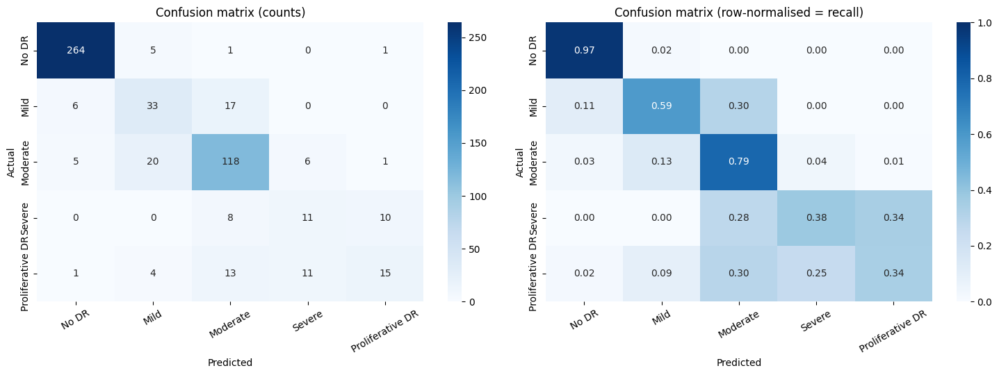

In [43]:
cm = confusion_matrix(y_test, test_pred, labels=range(NUM_CLASSES))
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[0])
ax[0].set_title('Confusion matrix (counts)')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax[1], vmin=0, vmax=1)
ax[1].set_title('Confusion matrix (row-normalised = recall)')
for a in ax:
    a.set_xlabel('Predicted'); a.set_ylabel('Actual'); a.tick_params(axis='x', rotation=30)
plt.tight_layout(); save_fig('12_confusion_matrix'); plt.show()

Plot **precision, recall and F1 for every stage** side by side, which shows at a glance which stages are easy and which are hard.

                  Precision  Recall  F1-score  Support
No DR                 0.957   0.974     0.965      271
Mild                  0.532   0.589     0.559       56
Moderate              0.752   0.787     0.769      150
Severe                0.393   0.379     0.386       29
Proliferative DR      0.556   0.341     0.423       44


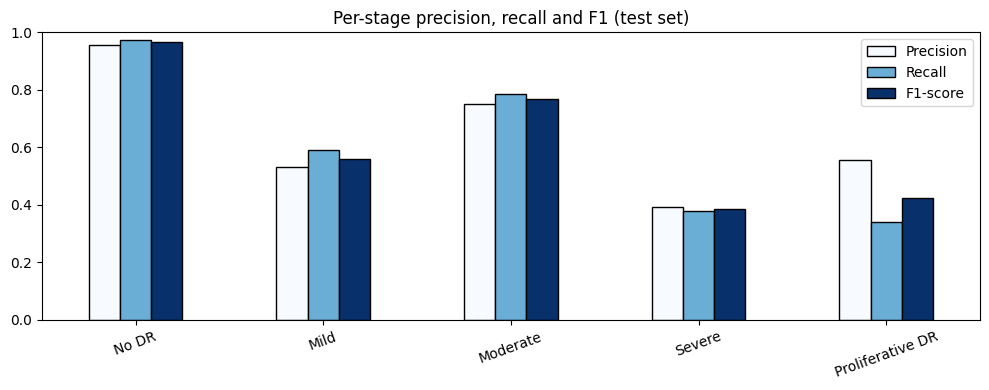

In [44]:
p, r, f, s = precision_recall_fscore_support(y_test, test_pred, labels=range(NUM_CLASSES), zero_division=0)
per_class = pd.DataFrame({'Precision': p, 'Recall': r, 'F1-score': f, 'Support': s}, index=CLASS_NAMES)
print(per_class.round(3))
per_class[['Precision', 'Recall', 'F1-score']].plot(kind='bar', figsize=(10, 4), colormap='Blues', edgecolor='black')
plt.ylim(0, 1); plt.title('Per-stage precision, recall and F1 (test set)'); plt.xticks(rotation=20)
plt.tight_layout(); save_fig('13_per_class_metrics'); plt.show()

**One-vs-rest ROC curves ** for every stage. The area under each curve (AUC) measures how well the model ranks that stage above the others, regardless of any decision threshold.

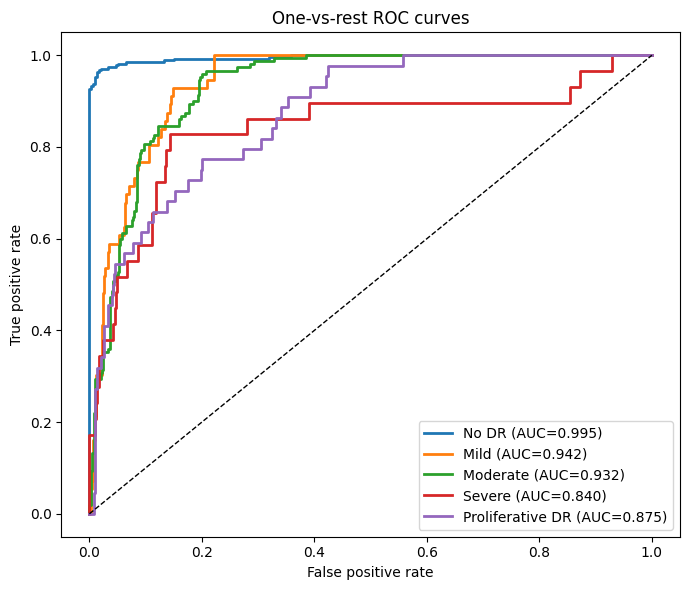

In [45]:
plt.figure(figsize=(7, 6))
for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve((y_test == c).astype(int), test_probs[:, c])
    plt.plot(fpr, tpr, lw=2, label=f'{CLASS_NAMES[c]} (AUC={roc_auc_score(y_test == c, test_probs[:, c]):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate'); plt.title('One-vs-rest ROC curves')
plt.legend(loc='lower right'); plt.tight_layout(); save_fig('14_roc_multiclass'); plt.show()

### Binary screening analysis 
The brief asks the system to classify **diabetic retinopathy as well as its stage**. `binary_screening_report` turns the 5-stage probabilities into two clinically used yes/no decisions:
- **Any DR**: stage ≥ 1, score = 1 − P(No DR)
- **Referable DR**: stage ≥ 2 (moderate or worse, the usual referral threshold in screening programmes), score = P(2) + P(3) + P(4)

For each decision it reports **sensitivity** (share of diseased eyes caught) and **specificity** (share of healthy eyes correctly cleared), plus ROC-AUC. The decision threshold is chosen on the **validation** set using Youden's J statistic, which maximises sensitivity + specificity.

Task                  Any DR (stage >= 1)  Referable DR (stage >= 2)
Threshold (from val)               0.4344                     0.2041
Sensitivity                        0.9785                     0.9686
Specificity                        0.9668                     0.8593
Precision (PPV)                    0.9681                     0.8244
NPV                                0.9776                     0.9757
Accuracy                           0.9727                     0.9036
ROC-AUC                            0.9952                     0.9786


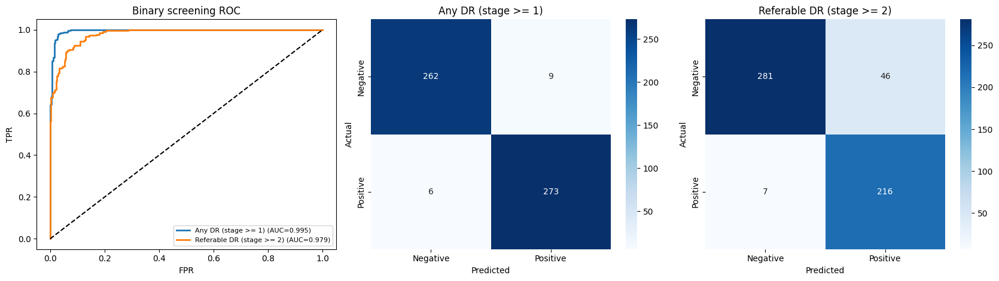

In [46]:
def binary_screening_report(name, min_stage):
    score_val = val_probs[:, min_stage:].sum(1)
    score_test = test_probs[:, min_stage:].sum(1)
    yv, yt = (y_val >= min_stage).astype(int), (y_test >= min_stage).astype(int)
    fpr_v, tpr_v, thr_v = roc_curve(yv, score_val)
    threshold = float(thr_v[np.argmax(tpr_v - fpr_v)])          # Youden's J on validation
    pred = (score_test >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, pred, labels=[0, 1]).ravel()
    out = {'Task': name, 'Threshold (from val)': threshold,
           'Sensitivity': tp / (tp + fn), 'Specificity': tn / (tn + fp),
           'Precision (PPV)': tp / max(tp + fp, 1), 'NPV': tn / max(tn + fn, 1),
           'Accuracy': (tp + tn) / len(yt), 'ROC-AUC': roc_auc_score(yt, score_test)}
    return out, yt, score_test, pred

binary_rows, fig_data = [], []
for name, stage in [('Any DR (stage >= 1)', 1), ('Referable DR (stage >= 2)', 2)]:
    row, yt, sc, pr = binary_screening_report(name, stage)
    binary_rows.append(row); fig_data.append((name, yt, sc, pr))
binary_df = pd.DataFrame(binary_rows).set_index('Task')
print(binary_df.round(4).T)
RESULTS['binary_screening'] = binary_df.round(4).to_dict('index')
REFERRAL_THRESHOLD = binary_df.loc['Referable DR (stage >= 2)', 'Threshold (from val)']

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for name, yt, sc, _ in fig_data:
    fpr, tpr, _ = roc_curve(yt, sc)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc_score(yt, sc):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--'); axes[0].legend(loc='lower right', fontsize=8)
axes[0].set_title('Binary screening ROC'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
for ax, (name, yt, _, pr) in zip(axes[1:], fig_data):
    sns.heatmap(confusion_matrix(yt, pr), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); save_fig('15_binary_screening'); plt.show()

### Error analysis
Because the stages are **ordinal**, an error from stage 2 to stage 3 is much less serious than an error from stage 0 to stage 4. This plot groups the test errors by **how many stages off** they are. The second plot compares the model's confidence on correct and incorrect predictions. If wrong predictions are usually low-confidence, uncertain cases can be routed automatically to a human grader.

Test errors: 109 of 550 | 76.1% of errors are only one stage away


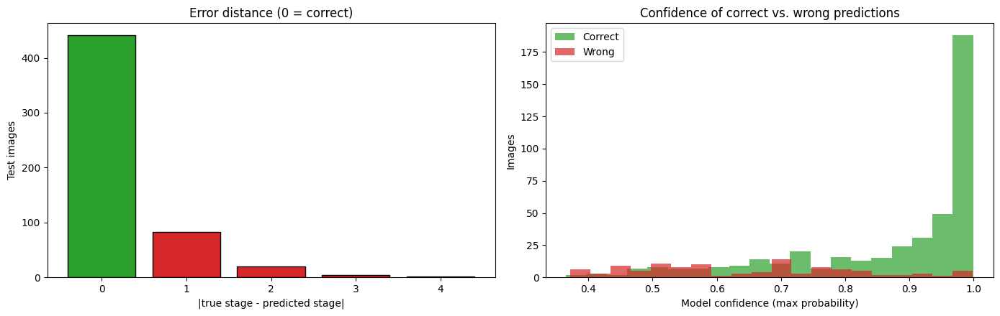

In [47]:
distance = np.abs(test_pred - y_test)
dist_counts = pd.Series(distance).value_counts().reindex(range(NUM_CLASSES), fill_value=0)
errors = distance > 0
adjacent_share = (distance == 1).sum() / max(errors.sum(), 1)
RESULTS['errors_adjacent_stage_pct'] = round(float(adjacent_share * 100), 1)
print(f'Test errors: {errors.sum()} of {len(y_test)} | {adjacent_share:.1%} of errors are only one stage away')

confidence = test_probs.max(1)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(dist_counts.index, dist_counts.values, color=['#2ca02c'] + ['#d62728'] * 4, edgecolor='black')
ax[0].set_xticks(range(NUM_CLASSES)); ax[0].set_xlabel('|true stage - predicted stage|')
ax[0].set_ylabel('Test images'); ax[0].set_title('Error distance (0 = correct)')
ax[1].hist(confidence[~errors], bins=20, alpha=0.7, label='Correct', color='#2ca02c')
ax[1].hist(confidence[errors], bins=20, alpha=0.7, label='Wrong', color='#d62728')
ax[1].set_xlabel('Model confidence (max probability)'); ax[1].set_ylabel('Images')
ax[1].set_title('Confidence of correct vs. wrong predictions'); ax[1].legend()
plt.tight_layout(); save_fig('16_error_analysis'); plt.show()

A gallery of **misclassified test images**, showing the true stage, the predicted stage and the confidence. Look at these when writing the critical discussion; most are typically borderline cases between neighbouring stages.

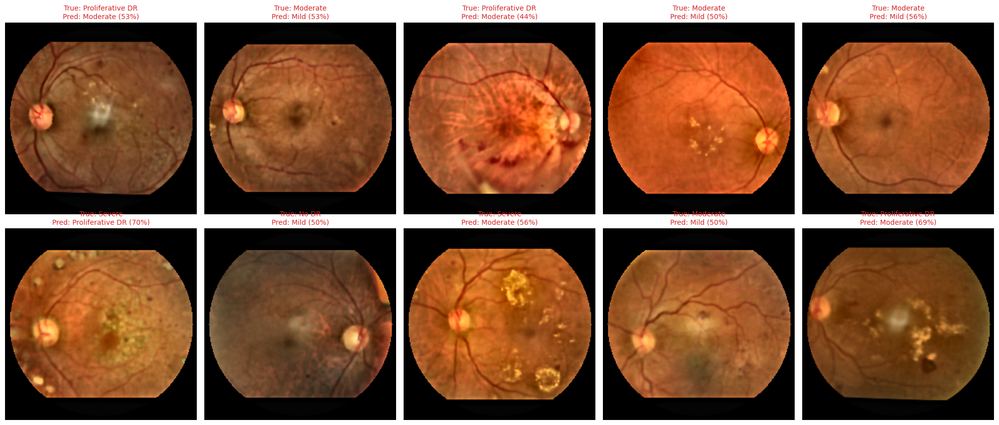

In [48]:
wrong = np.where(errors)[0]
show = np.random.default_rng(SEED).choice(wrong, size=min(10, len(wrong)), replace=False) if len(wrong) else []
if len(show):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8.5))
    for ax in axes.flat:
        ax.axis('off')
    for ax, i in zip(axes.flat, show):
        ax.imshow(X_test[i])
        ax.set_title(f'True: {CLASS_NAMES[y_test[i]]}\nPred: {CLASS_NAMES[test_pred[i]]} ({confidence[i]:.0%})',
                     fontsize=10, color='#d62728')
    plt.tight_layout(); save_fig('17_misclassified_examples'); plt.show()

## 9. Explainability with Grad-CAM (innovation & critical discussion)

**Gradient-weighted Class Activation Mapping** shows which regions of the retina drove each prediction. Clinicians are unlikely to trust a black-box score. A heatmap that lights up on haemorrhages or exudates is evidence the model uses medically meaningful features, while a heatmap on the image border or the optic disc would reveal a shortcut.

`find_last_conv_layer` finds the backbone's final convolutional feature map automatically, so Grad-CAM works for whichever backbone was selected.

In [49]:
def find_last_conv_layer(backbone):
    for layer in reversed(backbone.layers):
        if len(layer.output.shape) == 4:
            return layer
    raise ValueError('No 4D feature map found in backbone')

`build_gradcam_parts` splits the trained model into three pieces: any input-scaling layers, the backbone up to its last feature map, and the classification head (re-wired onto a new input using the **same trained layers**). Splitting the model like this avoids a Keras 3 limitation: the inner layers of a nested backbone cannot be reached through the outer model's graph.

In [50]:
def build_gradcam_parts(model, backbone):
    pos = model.layers.index(backbone)
    pre_layers = [l for l in model.layers[:pos] if not isinstance(l, layers.InputLayer)]
    last_conv = find_last_conv_layer(backbone)
    conv_model = keras.Model(backbone.inputs, last_conv.output)
    head_input = keras.Input(shape=last_conv.output.shape[1:])
    x = head_input
    for layer in model.layers[pos + 1:]:
        x = layer(x)
    return pre_layers, conv_model, keras.Model(head_input, x)

GRADCAM_PARTS = build_gradcam_parts(model, backbone)

`make_gradcam_heatmap` takes the gradient of the predicted class score with respect to the last feature map, averages it per channel to get importance weights, and forms a weighted sum of the channels. Negative values are clipped, and the result is normalised to [0, 1].

`overlay_heatmap` resizes the heatmap to image size, colours it and blends it over the retina, masked to the circular field of view.

In [51]:
def make_gradcam_heatmap(img, parts=None, class_index=None):
    pre_layers, conv_model, head_model = parts or GRADCAM_PARTS
    x = tf.convert_to_tensor(img[None].astype(np.float32))
    for layer in pre_layers:
        x = layer(x)
    with tf.GradientTape() as tape:
        conv_out = conv_model(x, training=False)
        tape.watch(conv_out)
        preds = head_model(conv_out, training=False)
        if class_index is None:
            class_index = int(tf.argmax(preds[0]))
        class_score = preds[:, class_index]
    grads = tape.gradient(class_score, conv_out)
    weights = tf.reduce_mean(grads, axis=(1, 2))                     # importance of each channel
    cam = tf.nn.relu(tf.reduce_sum(conv_out * weights[:, None, None, :], axis=-1))[0]
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    return cam.numpy(), class_index, preds.numpy()[0]

def overlay_heatmap(img, heatmap, alpha=0.45):
    heat = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heat = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * heat), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    blended = cv2.addWeighted(img.astype(np.uint8), 1 - alpha, heat, alpha, 0)
    return apply_circular_mask(blended)

Grad-CAM for **one test image of every stage**. A correctly predicted example is chosen where one exists. Rows show the preprocessed image, the raw heatmap and the overlay.

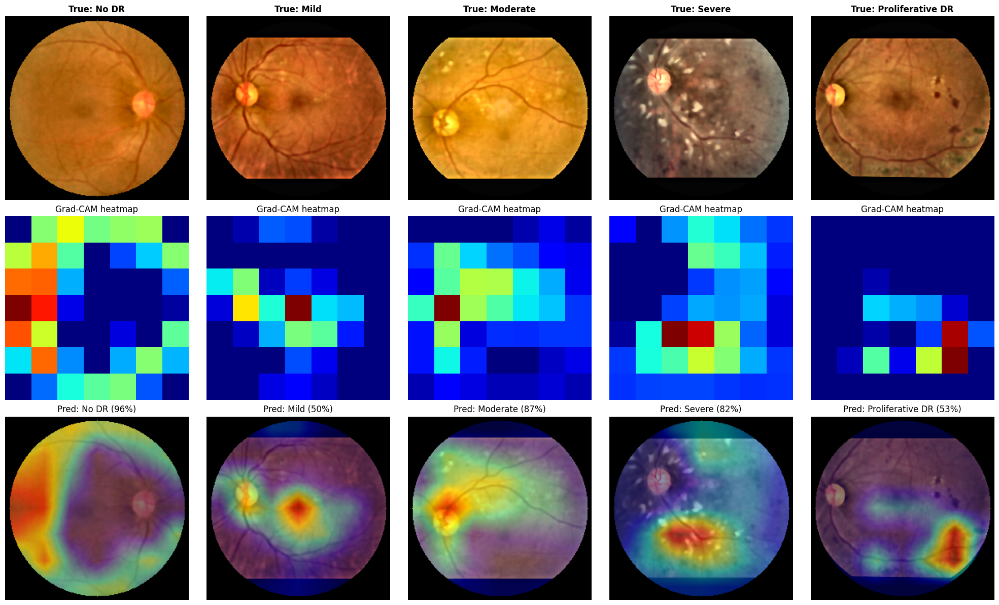

In [52]:
fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 12))
for c in range(NUM_CLASSES):
    candidates = np.where((y_test == c) & (test_pred == c))[0]
    if len(candidates) == 0:
        candidates = np.where(y_test == c)[0]
    i = candidates[0]
    heat, pred_c, probs = make_gradcam_heatmap(X_test[i])
    axes[0, c].imshow(X_test[i]); axes[0, c].set_title(f'True: {CLASS_NAMES[c]}', fontweight='bold')
    axes[1, c].imshow(heat, cmap='jet'); axes[1, c].set_title('Grad-CAM heatmap')
    axes[2, c].imshow(overlay_heatmap(X_test[i], heat))
    axes[2, c].set_title(f'Pred: {CLASS_NAMES[pred_c]} ({probs[pred_c]:.0%})')
for a in axes.flat:
    a.axis('off')
plt.tight_layout(); save_fig('18_gradcam_per_stage'); plt.show()

## 10. Deployment feasibility 

Would this model be usable in a real screening clinic? `deployment_profile` measures the practical numbers: parameter count, file size, **latency for one image** (what a clinician waits for) and **throughput** (images per second for batch screening).

In [53]:
def deployment_profile(m, n_runs=30):
    path = f'{OUT_DIR}/final_dr_model.keras'
    m.save(path)
    one = X_test[:1].astype(np.float32)
    m.predict(one, verbose=0)                              # warm-up
    start = time.perf_counter()
    for _ in range(n_runs):
        m.predict(one, verbose=0)
    latency_ms = (time.perf_counter() - start) / n_runs * 1000
    start = time.perf_counter()
    m.predict(X_test.astype(np.float32), batch_size=64, verbose=0)
    throughput = len(X_test) / (time.perf_counter() - start)
    return {'Parameters (M)': round(m.count_params() / 1e6, 2),
            'Keras file size (MB)': round(os.path.getsize(path) / 1e6, 1),
            'Latency per image (ms)': round(latency_ms, 1),
            'Throughput (images/s)': round(throughput, 1)}

RESULTS['deployment'] = deployment_profile(model)
print(pd.Series(RESULTS['deployment']))

Parameters (M)              4.38
Keras file size (MB)       52.90
Latency per image (ms)     92.50
Throughput (images/s)     243.60
dtype: float64


`convert_to_tflite` exports the model to **TensorFlow Lite** with dynamic-range (8-bit weight) quantisation, the format used on Android phones and low-cost edge devices, such as a smartphone attached to a portable fundus camera. It reports the size reduction and checks on 100 test images that the compressed model still agrees with the original. The cell is wrapped in `try/except`, so a converter problem cannot stop the rest of the notebook.

In [54]:
def convert_to_tflite(m, n_check=100):
    export_dir = f'{OUT_DIR}/saved_model_export'
    m.export(export_dir)
    converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_bytes = converter.convert()
    tflite_path = f'{OUT_DIR}/dr_model_quantized.tflite'
    with open(tflite_path, 'wb') as f:
        f.write(tflite_bytes)

    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    inp, out = interpreter.get_input_details()[0], interpreter.get_output_details()[0]
    preds = []
    for img in X_test[:n_check].astype(np.float32):
        interpreter.set_tensor(inp['index'], img[None])
        interpreter.invoke()
        preds.append(interpreter.get_tensor(out['index'])[0].argmax())
    agreement = np.mean(np.array(preds) == test_probs_plain[:n_check].argmax(1))
    return {'TFLite size (MB)': round(len(tflite_bytes) / 1e6, 1),
            'Size reduction vs .keras (%)': round(100 * (1 - len(tflite_bytes) / 1e6 / RESULTS['deployment']['Keras file size (MB)']), 1),
            f'Agreement with full model ({n_check} test images)': f'{agreement:.1%}'}

try:
    RESULTS['tflite'] = convert_to_tflite(model)
    print(pd.Series(RESULTS['tflite']))
except Exception as e:
    print('TFLite conversion skipped:', type(e).__name__, str(e)[:200])

INFO:tensorflow:Assets written to: /kaggle/working/saved_model_export/assets


INFO:tensorflow:Assets written to: /kaggle/working/saved_model_export/assets


Saved artifact at '/kaggle/working/saved_model_export'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134745412449872: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134742623250448: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134744382306064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134744382306448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134744382301840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134744382299344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134744382303568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134744382301072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134744382292816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134744382302992: TensorSpec(shape=(), dtype=tf.resource

W0000 00:00:1790849053.418691      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790849053.418737      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790849053.618992      58 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


TFLite size (MB)                                 4.9
Size reduction vs .keras (%)                    90.8
Agreement with full model (100 test images)    97.0%
dtype: object


## 11. Save results & prototype inference

Write every key result (configuration, experiments, test metrics, screening results, deployment numbers) to `results_summary.json`. That gives one file to copy numbers from when writing the report, and prints a clean summary.

In [55]:
RESULTS['config'] = {k: (v.item() if hasattr(v, 'item') else v) for k, v in CONFIG.items()}
RESULTS['use_tta'] = bool(USE_TTA)
RESULTS['referral_threshold'] = float(REFERRAL_THRESHOLD)
with open(f'{OUT_DIR}/results_summary.json', 'w') as f:
    json.dump(RESULTS, f, indent=2, default=lambda o: o.item() if hasattr(o, 'item') else str(o))

print('=' * 60)
print(f"FINAL MODEL: {CONFIG['BACKBONE']} | TTA: {USE_TTA}")
for k in ['Accuracy', 'Balanced accuracy', 'Macro F1', 'QWK', 'Macro ROC-AUC']:
    print(f"  {k:<20}: {RESULTS['test_metrics'][k]:.4f}")
ref = RESULTS['binary_screening']['Referable DR (stage >= 2)']
print(f"  Referable DR sensitivity / specificity: {ref['Sensitivity']:.3f} / {ref['Specificity']:.3f}")
print('=' * 60)
print('Saved: final_dr_model.keras, results_summary.json, test_metrics.csv, training logs, figures/')

FINAL MODEL: EfficientNetB0 | TTA: True
  Accuracy            : 0.8018
  Balanced accuracy   : 0.6141
  Macro F1            : 0.6204
  QWK                 : 0.8654
  Macro ROC-AUC       : 0.9168
  Referable DR sensitivity / specificity: 0.969 / 0.859
Saved: final_dr_model.keras, results_summary.json, test_metrics.csv, training logs, figures/


**Prototype in operation.** Reload the saved model from disk, as a fresh deployment would, and classify six unseen test photographs **straight from their original files** through the full preprocessing pipeline.

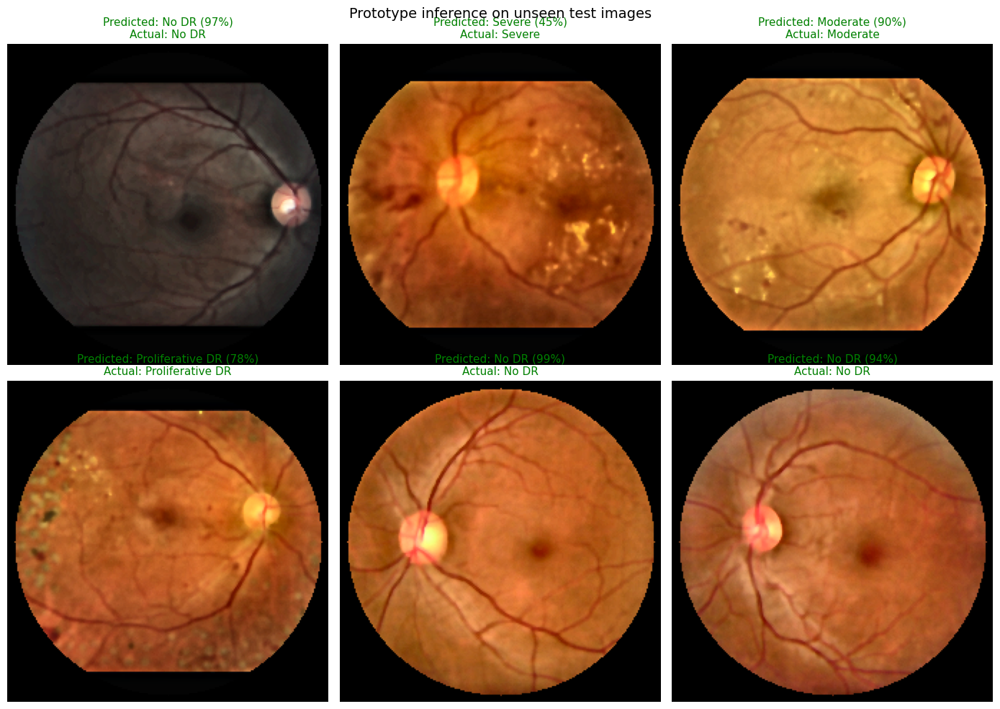

In [56]:
deployed_model = keras.models.load_model(f'{OUT_DIR}/final_dr_model.keras')

demo_rows = df.iloc[test_idx].sample(6, random_state=7)
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for ax, (_, row) in zip(axes.flat, demo_rows.iterrows()):
    img = preprocess_image(row['path'])
    probs = deployed_model.predict(img[None].astype(np.float32), verbose=0)[0]
    pred = int(probs.argmax())
    ax.imshow(img); ax.axis('off')
    ax.set_title(f"Predicted: {CLASS_NAMES[pred]} ({probs[pred]:.0%})\nActual: {row['stage']}",
                 color='green' if pred == row['diagnosis'] else 'red', fontsize=11)
plt.suptitle('Prototype inference on unseen test images', fontsize=14)
plt.tight_layout(); save_fig('19_prototype_inference'); plt.show()

## 12. Interactive prototype 

This turns the model into a small web application **upload any fundus photo** and see the predicted stage with probabilities, a screening recommendation and the Grad-CAM explanation, live.

`predict_for_app` reuses the **same** `preprocess_image`, model and Grad-CAM functions as the rest of the notebook. The referral recommendation uses the threshold chosen on the validation set in Section 8.

In [57]:
import gradio as gr

def predict_for_app(image):
    if image is None:
        return None, 'Please upload a retinal fundus photograph.', None
    processed = preprocess_image(image)                    # identical pipeline to training
    heat, pred_c, probs = make_gradcam_heatmap(processed)
    stage_probs = {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}
    p_referable = float(probs[2:].sum())
    if p_referable >= REFERRAL_THRESHOLD:
        advice = (f'### REFER to an ophthalmologist\nProbability of referable DR (moderate or worse): '
                  f'**{p_referable:.0%}** (threshold {REFERRAL_THRESHOLD:.0%})')
    else:
        advice = (f'### Routine re-screening\nProbability of referable DR: **{p_referable:.0%}** '
                  f'(below the {REFERRAL_THRESHOLD:.0%} referral threshold)')
    advice += '\n\n*Research prototype for decision support only - not a certified medical device.*'
    return stage_probs, advice, overlay_heatmap(processed, heat)

Build and launch the interface. `share=True` creates a temporary public link, handy for recording in a clean browser tab. `allowed_paths` lets Gradio display the example images stored in Kaggle's read-only input folder. `prevent_thread_lock=True` keeps the notebook usable while the app runs.

In [58]:
example_paths = [df.iloc[test_idx][df.iloc[test_idx]['diagnosis'] == c]['path'].iloc[0] for c in [0, 2, 4]]

demo = gr.Interface(
    fn=predict_for_app,
    inputs=gr.Image(type='numpy', label='Upload a retinal fundus photograph'),
    outputs=[gr.Label(num_top_classes=NUM_CLASSES, label='Predicted DR stage'),
             gr.Markdown(label='Screening recommendation'),
             gr.Image(label='Grad-CAM: regions that influenced the prediction')],
    title='Diabetic Retinopathy Screening Assistant',
    description=(f"{CONFIG['BACKBONE']} transfer-learning model trained on APTOS 2019. "
                 'Upload a photo to get the DR stage, a referral recommendation and a visual explanation.'),
    examples=example_paths,
)
demo.launch(share=True, prevent_thread_lock=True, allowed_paths=[IMG_DIR, OUT_DIR])

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://51d03cce40dba6e118.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Shut the app down after recording. Before using **Save Version → Save & Run All (Commit)**, delete or skip the two Gradio cells, because a live server can block a non-interactive run.

In [ ]:
demo.close()

### Extra work beyond the brief
1. **Image-quality metrics** that measure whether preprocessing actually improved the images (contrast, entropy, sharpness)
2. **Backbone comparison** of EfficientNetB0, ResNet50V2 and MobileNetV2 before choosing the final model
3. **Hyperparameter search** over learning rate and head size
4. **Combined model-selection score** (macro F1 + quadratic weighted kappa) that cannot be gamed by predicting only the majority class
5. **Test-time augmentation (TTA)**, accepted or rejected on the validation set rather than the test set
6. **Binary screening analysis** (sensitivity, specificity, ROC-AUC, threshold chosen on validation data)
7. **Multi-class ROC curves**, error-distance analysis, confidence analysis and a gallery of misclassified images
8. **Grad-CAM explainability** for every stage
9. **Deployment feasibility**: model size, inference latency and a quantised TensorFlow Lite version
10. **Interactive Gradio prototype** with a referral recommendation, for the video demonstration